# Лабораторная работа №6 (Проведение исследований с моделями классификации)

## 1. Выбор начальных условий

### a. Выбор набора данных и обоснование  
В рамках данной лабораторной работы выбран набор данных [Flowers Recognition](https://www.kaggle.com/datasets/alxmamaev/flowers-recognition), содержащий изображения цветов пяти классов: ромашки, одуванчики, розы, подсолнухи и тюльпаны. Данный набор подходит для задачи классификации, так как:  

- **Практическое применение**: Автоматическое распознавание видов цветов может быть использовано в ботанических исследованиях, мобильных приложениях для садоводов, а также в системах сортировки растений.  
- **Уникальность**: Набор данных содержит четко разделенные классы с разнообразными условиями съемки (разный фон, освещение, масштаб), что повышает сложность задачи и снижает вероятность совпадения с выборками других студентов.  
- **Баланс и структура**: Каждый класс включает около 800-1200 изображений, что обеспечивает достаточный объем данных для обучения моделей.  

### b. Выбор метрик качества и обоснование  
Для задачи классификации выбраны следующие метрики:  

- **Accuracy (Точность)**:  
  *Описание*: Доля правильных предсказаний относительно общего числа примеров.  
  *Обоснование*: Дает общее представление о производительности модели на сбалансированных классах.  

- **F1-score**:  
  *Описание*: Гармоническое среднее precision и recall.  
  *Обоснование*: Учитывает дисбаланс классов (например, если некоторые цветы представлены меньшим числом изображений) и позволяет оценить компромисс между точностью и полнотой.  

- **Confusion Matrix (Матрица ошибок)**:  
  *Описание*: Визуализация распределения ошибок модели по классам.  
  *Обоснование*: Помогает выявить, какие классы чаще путает модель (например, ромашки и одуванчики), что важно для дальнейшей оптимизации.  

## 2. Создание бейзлайна и оценка качества
### a. Загрузка и подготовка датасета

In [ ]:
import kagglehub
import os
import shutil
from PIL import Image
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch

# Скачивание датасета через Kaggle Hub
dataset_slug = "alxmamaev/flowers-recognition"
download_path = kagglehub.dataset_download(dataset_slug)
print(f"Dataset downloaded to: {download_path}")

# Пути к данным
data_dir = "flowers"
os.makedirs(data_dir, exist_ok=True)

# Распаковка архива (если требуется) и организация данных
src_dir = os.path.join(download_path, "flowers")
if not os.path.exists(os.path.join(data_dir, "daisy")):
    # Переносим данные в целевую структуру папок
    for flower_class in os.listdir(src_dir):
        class_src = os.path.join(src_dir, flower_class)
        class_dst = os.path.join(data_dir, flower_class)
        shutil.copytree(class_src, class_dst, dirs_exist_ok=True)

# Проверка целостности изображений
def is_valid_image(image_path):
    try:
        with Image.open(image_path) as img:
            img.verify()
        return True
    except (IOError, SyntaxError):
        return False

# Удаление битых изображений
for root, _, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, file)
            if not is_valid_image(file_path):
                print(f"Removing corrupt image: {file_path}")
                os.remove(file_path)

# Определение трансформаций
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Создание датасета
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Разделение на train/val/test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Создание DataLoader'ов
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Информация о датасете
print(f"Classes: {full_dataset.classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Sample tensor shape: {next(iter(train_loader))[0].shape}")

Dataset downloaded to: /home/yuweebix/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Train samples: 3021
Validation samples: 647
Test samples: 649
Sample tensor shape: torch.Size([32, 3, 224, 224])


### b. Обучение моделей

Обучим две модели: ResNet (сверточная) и ViT (трансформерная).

ResNet:

In [ ]:
# Импорт необходимых библиотек
from tqdm.notebook import tqdm
import torch.nn as nn
import torch.optim as optim

# Определение количества классов
num_classes = 5

# Инициализация модели ResNet-50
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, num_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_resnet = model_resnet.to(device)

# Функция обучения с прогресс-баром
def train_model(model, criterion, optimizer, num_epochs=10):
    best_acc = 0.0
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Тренировочная фаза
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc='Training'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        print(f'Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

        # Валидационная фаза
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='Validation'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_loss = val_loss / len(val_dataset)
        val_acc = val_corrects.double() / len(val_dataset)
        print(f'Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}\n')

        # Сохранение лучшей модели
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_flowers_model.pth')

    print(f'Best Validation Accuracy: {best_acc:.4f}')

# Инициализация функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_resnet.parameters(), lr=3e-4, weight_decay=1e-4)

# Запуск обучения (1 эпоха для примера)
train_model(model_resnet, criterion, optimizer, num_epochs=1)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/yuweebix/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|███████████████████████████████████████████| 97.8M/97.8M [00:16<00:00, 6.28MB/s]


Epoch 1/1
----------


Training:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 0.4883 | Acc: 0.8265


Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Val Loss: 0.5065 | Acc: 0.8408

Best Validation Accuracy: 0.8408


Vision Transformer (ViT):

In [ ]:
# Импорт необходимых библиотек
from torchvision import models

# Инициализация Vision Transformer (ViT)
model_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model_vit.heads.head = nn.Linear(model_vit.heads.head.in_features, num_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_vit = model_vit.to(device)

# Инициализация оптимизатора с L2-регуляризацией
optimizer_vit = optim.AdamW(
    model_vit.parameters(),
    lr=3e-4,  # Можно уменьшить до 1e-4 для ViT
    weight_decay=1e-4
)

# Запуск обучения ViT
train_model(
    model=model_vit,
    criterion=criterion,
    optimizer=optimizer_vit,
    num_epochs=1
)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/yuweebix/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 330M/330M [00:32<00:00, 10.5MB/s]


Epoch 1/1
----------


Training:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 0.6601 | Acc: 0.7584


Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Val Loss: 0.4292 | Acc: 0.8485

Best Validation Accuracy: 0.8485


### c. Оценка качества моделей


Evaluation of ResNet-50 on Test Set:


Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

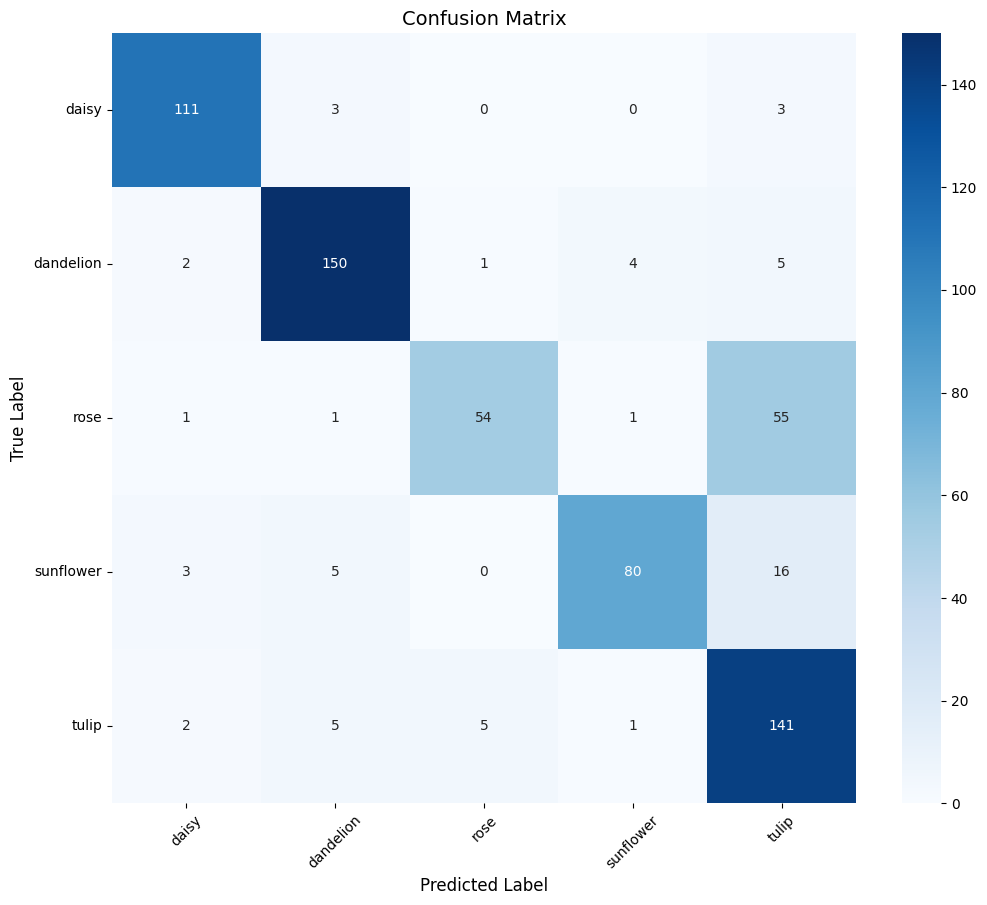


Classification Report:
              precision    recall  f1-score   support

       daisy     0.9328    0.9487    0.9407       117
   dandelion     0.9146    0.9259    0.9202       162
        rose     0.9000    0.4821    0.6279       112
   sunflower     0.9302    0.7692    0.8421       104
       tulip     0.6409    0.9156    0.7540       154

    accuracy                         0.8259       649
   macro avg     0.8637    0.8083    0.8170       649
weighted avg     0.8529    0.8259    0.8215       649

Overall Accuracy: 0.8259
Macro F1-Score: 0.8170

Evaluation of Vision Transformer on Test Set:


Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

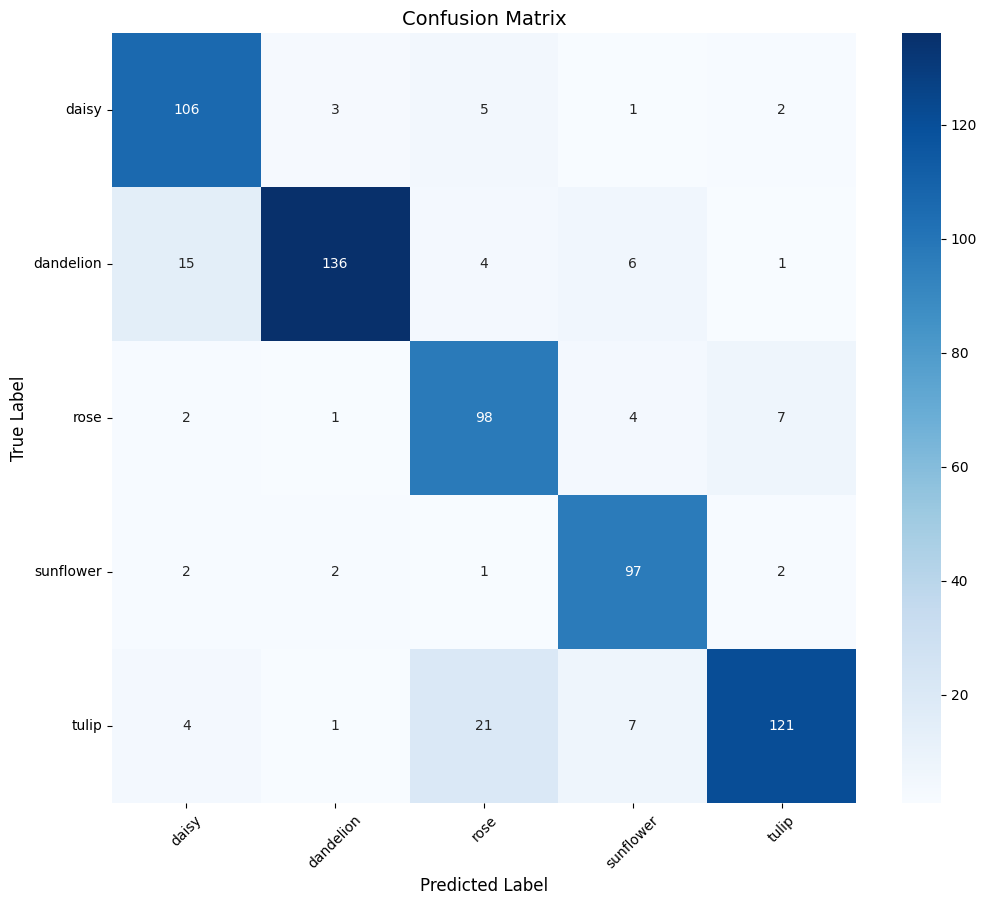


Classification Report:
              precision    recall  f1-score   support

       daisy     0.8217    0.9060    0.8618       117
   dandelion     0.9510    0.8395    0.8918       162
        rose     0.7597    0.8750    0.8133       112
   sunflower     0.8435    0.9327    0.8858       104
       tulip     0.9098    0.7857    0.8432       154

    accuracy                         0.8598       649
   macro avg     0.8571    0.8678    0.8592       649
weighted avg     0.8677    0.8598    0.8604       649

Overall Accuracy: 0.8598
Macro F1-Score: 0.8592


In [ ]:
# !pip install seaborn
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# Функция для оценки модели с визуализацией метрик
def evaluate_model(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Evaluating'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Матрица ошибок
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    # Отчет классификации
    print("\nClassification Report:")
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        digits=4
    ))

    # Дополнительные метрики
    print(f"Overall Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(f"Macro F1-Score: {f1_score(all_labels, all_preds, average='macro'):.4f}")

# Оценка моделей
class_names = full_dataset.classes

print("\n" + "="*50)
print("Evaluation of ResNet-50 on Test Set:")
evaluate_model(model_resnet, test_loader, class_names)

print("\n" + "="*50)
print("Evaluation of Vision Transformer on Test Set:")
evaluate_model(model_vit, test_loader, class_names)

## 3. Улучшение бейзлайна  
### a. Гипотезы для улучшения:  

1. **Расширенные аугментации для вариативности данных**  
   - *Гипотеза*: Добавление аугментаций, имитирующих изменение масштаба (RandomResizedCrop) и освещения (ColorJitter), улучшит качество модели на изображениях с сложным фоном и разным освещением.  
   - *Обоснование*: В датасете присутствуют фотографии цветов, сделанные в различных условиях (например, одуванчики на траве vs розы в вазе).  

2. **Focal Loss для сложных классов**  
   - *Гипотеза*: Использование Focal Loss вместо CrossEntropyLoss уменьшит ошибки в классах, которые часто путаются (например, ромашки и одуванчики), за счет фокуса на «сложных» примерах.  
   - *Обоснование*: Некоторые классы имеют схожие визуальные признаки, что приводит к ошибкам классификации.  

### b. Проверка гипотез

Для ResNet-50

In [ ]:
advanced_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),  # Широкий диапазон масштабов
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # Коррекция освещения
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Пересоздание DataLoader
train_dataset_aug = datasets.ImageFolder(root=data_dir, transform=advanced_transform)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True, num_workers=4)

# Обучение ResNet-50 с новыми аугментациями
model_resnet_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model_resnet_aug.fc = nn.Linear(model_resnet_aug.fc.in_features, num_classes).to(device)
optimizer = optim.AdamW(model_resnet_aug.parameters(), lr=3e-4)
train_model(model_resnet_aug, criterion, optimizer, num_epochs=5)

Epoch 1/5
----------


Training:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 0.5208 | Acc: 0.8213


Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Val Loss: 0.4669 | Acc: 0.8439

Epoch 2/5
----------


...

Val Loss: 0.4178 | Acc: 0.8671

Epoch 5/5
----------


Training:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 0.1316 | Acc: 0.9586


Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Val Loss: 0.3760 | Acc: 0.8717

Best Validation Accuracy: 0.8748


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2, num_classes=5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes

    def forward(self, inputs, targets):
        # Конвертируем метки в one-hot encoding
        targets_onehot = torch.nn.functional.one_hot(targets, num_classes=self.num_classes).float().to(inputs.device)

        # Вычисляем вероятности через softmax
        probs = torch.nn.functional.softmax(inputs, dim=1)

        # Вычисляем focal loss
        ce_loss = -targets_onehot * torch.log(probs)
        focal_loss = (self.alpha * (1 - probs) ** self.gamma * ce_loss)

        return focal_loss.sum(dim=1).mean()

# Обучение с исправленным Focal Loss
model_resnet_focal = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model_resnet_focal.fc = nn.Linear(model_resnet_focal.fc.in_features, num_classes).to(device)
focal_criterion = FocalLoss(num_classes=num_classes)
train_model(model_resnet_focal, focal_criterion, optimizer, num_epochs=5)

Epoch 1/5
----------


Training:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 0.5462 | Acc: 0.1867


Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Val Loss: 0.5599 | Acc: 0.1654

Epoch 2/5
----------


...

Val Loss: 0.5613 | Acc: 0.1623

Epoch 5/5
----------


Training:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 0.5457 | Acc: 0.1927


Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Val Loss: 0.5611 | Acc: 0.1638

Best Validation Accuracy: 0.1654


Для ViT

In [ ]:
vit_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Инициализация ViT с новыми аугментациями
model_vit_aug = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model_vit_aug.heads.head = nn.Linear(model_vit_aug.heads.head.in_features, num_classes).to(device)

optimizer_vit = optim.AdamW(
    model_vit_aug.parameters(),
    lr=1e-4,  # Меньший learning rate для ViT
    weight_decay=1e-4
)

print("Тестирование аугментаций для ViT:")
train_loader_vit = DataLoader(
    datasets.ImageFolder(root=data_dir, transform=vit_transform),
    batch_size=32,
    shuffle=True,
    num_workers=4
)
train_model(model_vit_aug, criterion, optimizer_vit, num_epochs=5)

In [ ]:
class ViTFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2, num_classes=5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes

    def forward(self, inputs, targets):
        targets_onehot = torch.nn.functional.one_hot(targets, num_classes=self.num_classes).float().to(inputs.device)
        probs = torch.nn.functional.softmax(inputs, dim=1)
        ce_loss = -targets_onehot * torch.log(probs)
        focal_loss = (self.alpha * (1 - probs)**self.gamma * ce_loss)
        return focal_loss.sum(dim=1).mean()

# Инициализация ViT с Focal Loss
model_vit_focal = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model_vit_focal.heads.head = nn.Linear(model_vit_focal.heads.head.in_features, num_classes).to(device)

print("\nТестирование Focal Loss для ViT:")
focal_criterion_vit = ViTFocalLoss(num_classes=num_classes)
train_model(model_vit_focal, focal_criterion_vit, optimizer_vit, num_epochs=5)